# Heating a gas at one pressure: NPT and the compressibility factor

We vary temperature while keeping the **target pressure fixed** at P = 0.05.
This is a Lennard–Jones gas in shared reduced units, not a fit to a real substance.
Each temperature is simulated independently, allowed to equilibrate, and then
measured. The saved files let us make all plots again without rerunning MD.

At fixed pressure, the ideal gas expands as V = N T / P. We ask whether the LJ
gas follows that prediction. P(T) should be nearly flat: it checks the barostat.
The interesting response is V(T), and Z(T) = P mean(V) / (N T).


In [1]:
from fys2160_md import FCC, MDSimulation, Run
import numpy as np
import matplotlib.pyplot as plt

temperatures = [1.5, 2.0, 2.5, 3.0]
target_pressure = 0.05
N = 108

## Equilibrate and record each temperature

NPT uses a thermostat and a barostat: both temperature and pressure fluctuate
around their targets, while the box changes size. Density 0.025 sets only the
starting box. `pressure_time` controls the barostat timescale.

`timestep=0.005` advances the physical state; `thermo_every=100` records numbers
every 0.5 reduced time units; `trajectory_every=1000` records coordinates every 5.
The first 10,000 steps equilibrate (time 50), and the next 20,000 steps measure
(time 100). These lengths illustrate the method; inspect the traces and extend
the runs if their averages still drift. Each production run has its own name.


In [2]:
for temperature in temperatures:
    system = FCC(N=N, rho=0.025)
    sim = MDSimulation(
        system,
        pair_potential="lj",
        epsilon=1,
        sigma=1,
        ensemble="npt",
        temperature=temperature,
        pressure=target_pressure,
        timestep=0.005,
        cutoff=2.5,
        friction=1,
        pressure_time=5,
        seed=87287,
    )
    sim.run(
        steps=10_000,
        thermo_every=100,
        trajectory_every=None,
        storage_name=f"npt-equilibrate-T{temperature:g}",
    )
    sim.run(
        steps=20_000,
        thermo_every=100,
        trajectory_every=1000,
        storage_name=f"npt-T{temperature:g}",
    )

## Read the measurements from disk

Only production files enter the averages. In NPT, we know the imposed P and T,
so the equation-of-state estimate is **Z = P_target × mean(V) / (N × T_target)**.
The measured mean pressure and temperature are separate checks that the controls
have settled. This is not the mean of the instantaneous Z column: averages of
products or ratios need not equal products or ratios of averages.

You can run the cells below in a fresh session after the imports/settings cell.
No simulation is performed by `Run.load`.


In [3]:
mean_temperatures = []
mean_pressures = []
mean_volumes = []
Z = []

for temperature in temperatures:
    saved = Run.load(f"runs/npt-T{temperature:g}")
    data = saved.thermo
    mean_temperatures.append(data.temperature.mean())
    mean_pressures.append(data.pressure.mean())
    mean_volumes.append(data.volume.mean())
    Z.append(target_pressure * data.volume.mean() / (N * temperature))

print("T target  T mean   P mean   mean V     Z")
for T, measured_T, P, V, z in zip(
    temperatures, mean_temperatures, mean_pressures, mean_volumes, Z
):
    print(f"{T:8.2f} {measured_T:7.3f} {P:8.4f} {V:8.1f} {z:7.3f}")

T target  T mean   P mean   mean V     Z
    1.50   1.499   0.0506   3062.5   0.945
    2.00   1.996   0.0499   4229.4   0.979
    2.50   2.506   0.0499   5393.8   0.999
    3.00   3.004   0.0502   6488.1   1.001


## P(T), V(T), and Z(T) at one target pressure

The dashed lines show the target pressure and ideal-gas predictions. A value
Z < 1 means a smaller mean volume than the ideal gas at the same imposed P and T;
Z > 1 means a larger volume. Short, finite-system runs have statistical scatter,
so small departures from one should not be overinterpreted.


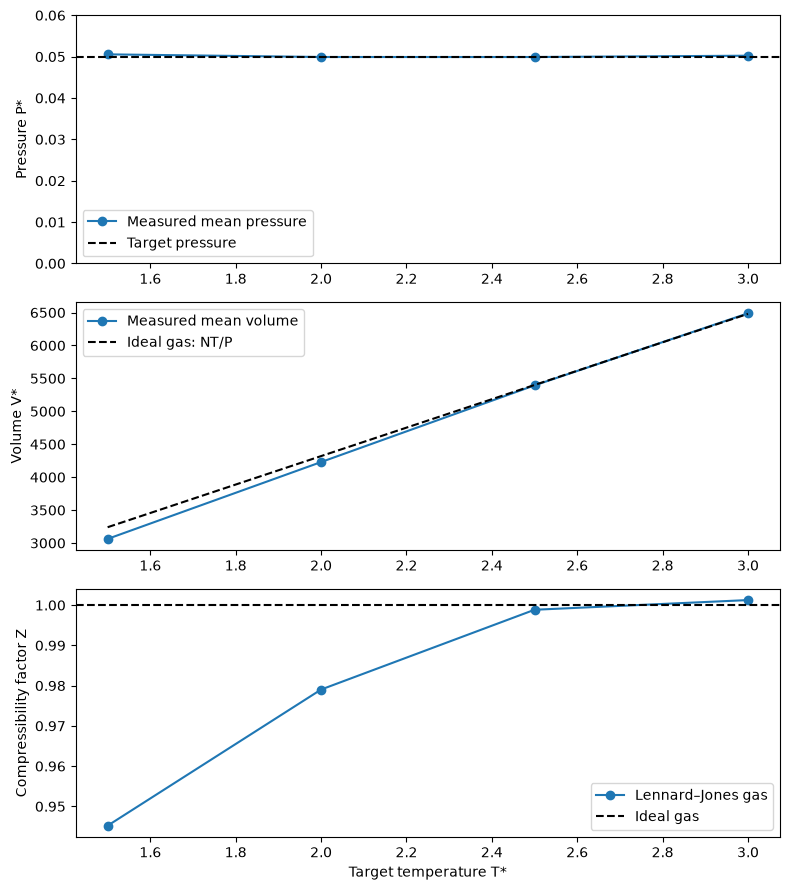

In [4]:
T = np.array(temperatures)

plt.figure(figsize=(8, 9))
plt.subplot(3, 1, 1)
plt.plot(T, mean_pressures, "o-", label="Measured mean pressure")
plt.axhline(target_pressure, color="black", linestyle="--", label="Target pressure")
plt.ylabel("Pressure P*")
plt.ylim(0, 1.2 * target_pressure)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(T, mean_volumes, "o-", label="Measured mean volume")
plt.plot(T, N * T / target_pressure, "--", color="black", label="Ideal gas: NT/P")
plt.ylabel("Volume V*")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(T, Z, "o-", label="Lennard–Jones gas")
plt.axhline(1, color="black", linestyle="--", label="Ideal gas")
plt.ylabel("Compressibility factor Z")
plt.xlabel("Target temperature T*")
plt.legend()
plt.tight_layout()
plt.show()

## Inspect one production run

These traces help us judge fluctuations and drift, rather than relying on one
average alone. The time axis continues from equilibration. The player uses the
same saved production trajectory; it does not run another simulation.


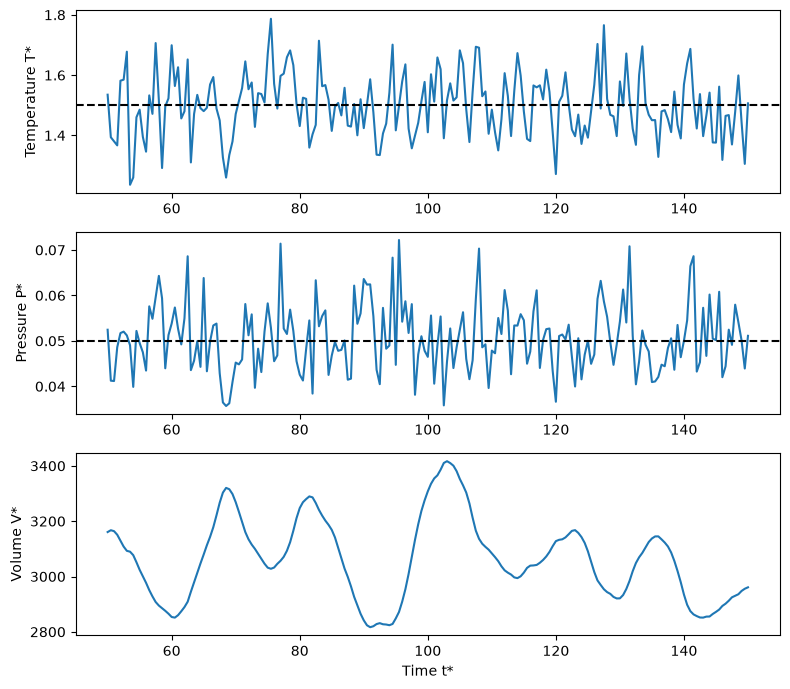

In [5]:
saved = Run.load("runs/npt-T1.5")
data = saved.thermo

plt.figure(figsize=(8, 7))
plt.subplot(3, 1, 1)
plt.plot(data.time, data.temperature)
plt.axhline(1.5, color="black", linestyle="--")
plt.ylabel("Temperature T*")
plt.subplot(3, 1, 2)
plt.plot(data.time, data.pressure)
plt.axhline(target_pressure, color="black", linestyle="--")
plt.ylabel("Pressure P*")
plt.subplot(3, 1, 3)
plt.plot(data.time, data.volume)
plt.ylabel("Volume V*")
plt.xlabel("Time t*")
plt.tight_layout()
plt.show()

saved.view(projection="perspective")